In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import confusion_matrix   
from sklearn.metrics import r2_score 

## **real_estate**

In [2]:
df= pd.read_csv('real_estate.csv')
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


**1-Je supprime la colonne 'No' d'indexion pas très utile**

In [3]:
df= df.drop(['No'], axis=1)
df

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...
409,2013.000,13.7,4082.01500,0,24.94155,121.50381,15.4
410,2012.667,5.6,90.45606,9,24.97433,121.54310,50.0
411,2013.250,18.8,390.96960,7,24.97923,121.53986,40.6
412,2013.000,8.1,104.81010,5,24.96674,121.54067,52.5


**2-Suppression des lignes détenants des variables sans valeurs**

In [4]:
df= df.dropna(axis=0)
df

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...
409,2013.000,13.7,4082.01500,0,24.94155,121.50381,15.4
410,2012.667,5.6,90.45606,9,24.97433,121.54310,50.0
411,2013.250,18.8,390.96960,7,24.97923,121.53986,40.6
412,2013.000,8.1,104.81010,5,24.96674,121.54067,52.5


**3-Conversion des valeurs décimales des colonnes 'X1 transaction date' et 'X2 house age' en entier**

In [5]:
df['X1 transaction date']= df['X1 transaction date'].astype(int)
df['X2 house age']= df['X2 house age'].astype(int)
df

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,2012,32,84.87882,10,24.98298,121.54024,37.9
1,2012,19,306.59470,9,24.98034,121.53951,42.2
2,2013,13,561.98450,5,24.98746,121.54391,47.3
3,2013,13,561.98450,5,24.98746,121.54391,54.8
4,2012,5,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...
409,2013,13,4082.01500,0,24.94155,121.50381,15.4
410,2012,5,90.45606,9,24.97433,121.54310,50.0
411,2013,18,390.96960,7,24.97923,121.53986,40.6
412,2013,8,104.81010,5,24.96674,121.54067,52.5


**4-Carte de corrélation des différentes variables du dataset**

<Axes: >

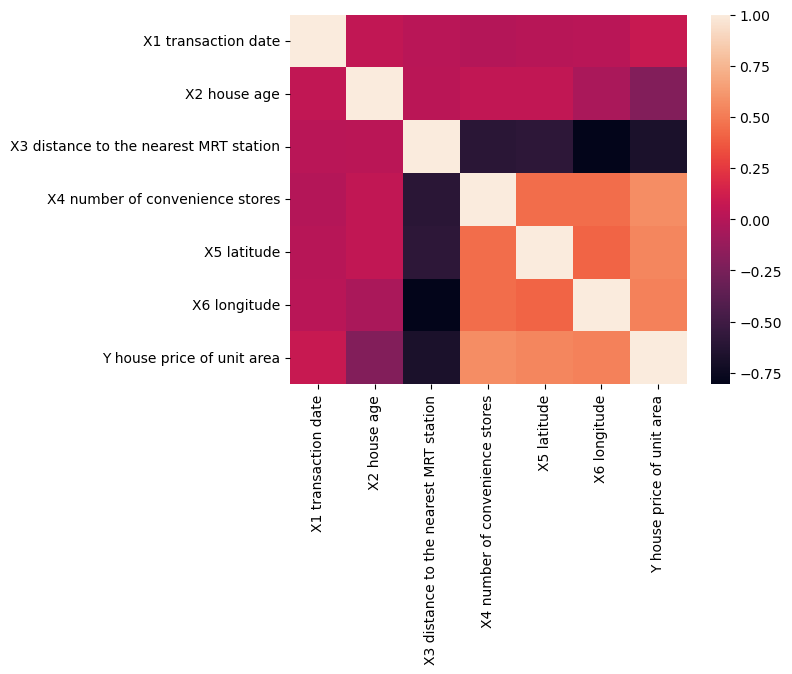

In [6]:
sns.heatmap(df.corr())

##### On peut voir sur ce carte que **le prix de la maison à la superficie unitaire** est fortement corréler avec **le nombre de magasins de proximité**, la **latitude** et la **longitude**.

   **5-Mise en place des features(x) et du target(y)**

In [7]:
x= df.drop(["Y house price of unit area"], axis=1)
y= df['Y house price of unit area']

**6-Constitution des données d'entrainement et de test (trainset, testset)**

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

**7-Entrainement du model et calcul du score r2**

In [9]:
def scoreR2(estimator):
    model=estimator
    model.fit(x_train, y_train)
    y_pred= model.predict(x_test)
    score_r2= r2_score(y_test, y_pred)

    print(f"Score R2: {score_r2 * 100:.2f} %")
    #print(confusion_matrix(y_test, y_pred))

    print(f"\n Score: {model.score(x_test,y_test)*100:.2f} %")

In [10]:
model= RandomForestRegressor(n_estimators=40, random_state=13)
scoreR2(model)  

Score R2: 70.13 %

 Score: 70.13 %


In [11]:
model= RandomForestRegressor(n_estimators=400, random_state=4)
scoreR2(model)  

Score R2: 66.11 %

 Score: 66.11 %


In [12]:
from sklearn.tree import DecisionTreeRegressor
model= DecisionTreeRegressor(random_state=9)
scoreR2(model)

Score R2: 33.00 %

 Score: 33.00 %


In [13]:
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import accuracy_score, f1_score
# Créer et entraîner le réseau neuronal avec une seule couche cachée de 5 neurones
model = MLPRegressor(hidden_layer_sizes=(10,), max_iter=10000, random_state=68)
model.fit(x_train, y_train)

# Prédire sur les données de test
y_pred = model.predict(x_test)

# Calculer et afficher le score R2
r2 = r2_score(y_test, y_pred)
print(f"Score R2: {r2*100:.2f}%")

Score R2: 69.42%


In [14]:
# Créer et entraîner le réseau neuronal avec une seule couche cachée de 10 neurones
model = MLPRegressor(hidden_layer_sizes=(10,), max_iter=10000, random_state=68)
model.fit(x_train, y_train)

# Prédire sur les données de test
y_pred = model.predict(x_test)

# Calculer et afficher le score R2
r2 = r2_score(y_test, y_pred)
print(f"Score R2: {r2*100:.2f}%")

Score R2: 69.42%


## **Iris.xls**

In [15]:
%pip install xlrd

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [16]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import seaborn as sns

# Charger la base de données Iris1.csv
data = pd.read_excel('Iris.xls')
data.head()

,sepal length,sepal width,petal length,petal width,iris
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [17]:
data.shape

(150, 5)

In [18]:
data["iris"].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

<Axes: >

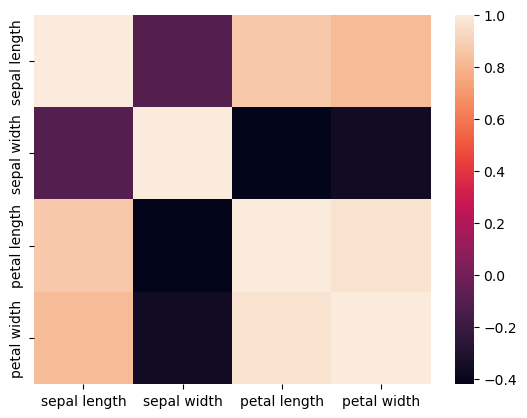

In [19]:
sns.heatmap(data[["sepal length", "sepal width", "petal length", "petal width"]].corr())

In [20]:
from sklearn.metrics import f1_score
# Séparer les caractéristiques (features) et la cible (target)
X = data.drop(columns=['iris'])
y = data['iris']

# Diviser les données en base d'apprentissage (80%) et base de test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=59)

# Créer et entraîner le réseau neuronal avec une seule couche cachée de 5 neurones
model = MLPClassifier(hidden_layer_sizes=(5,), max_iter=10000, random_state=59)
model.fit(X_train, y_train)

# Prédire sur les données de test
y_pred = model.predict(X_test)

# Calcule et affichage de l'exactitude (accuracy)
accuracy = accuracy_score(y_test, y_pred)

# Calculer et afficher la mesure F1
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Exactitude: {accuracy * 100:.2f}%")
print(f"Mesure F1: {f1*100:.2f}%")

print(f"\n confusion_matrix: \n{confusion_matrix(y_test, y_pred)}")

Exactitude: 96.67%
Mesure F1: 96.70%

 confusion_matrix: 
[[ 9  0  0]
 [ 0  8  0]
 [ 0  1 12]]


In [21]:
model= RandomForestClassifier(n_estimators=40, random_state=13)
model.fit(X_train, y_train)
y_pred= model.predict(X_test)  
score= f1_score(y_test, y_pred, average='weighted') 
print(f"Mesure F1: {score*100:.2f}")
print(f"\n Scrore: {model.score(X_test, y_test)*100:.2f}")

print(f"\n confusion_matrix: \n{confusion_matrix(y_test, y_pred)}")

Mesure F1: 96.70

 Scrore: 96.67

 confusion_matrix: 
[[ 9  0  0]
 [ 0  8  0]
 [ 0  1 12]]


In [22]:
# Créer et entraîner le réseau neuronal avec deux couches cachées de 10 neurones chacune
model = MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=10000, random_state=42)
model.fit(X_train, y_train)

# Prédire sur les données de test
y_pred = model.predict(X_test)

# Calcule et affichage l'exactitude (accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitude: {accuracy * 100:.2f}%")

# Calculer et afficher la mesure F1
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"Mesure F1: {f1*100:.2f}%")

print(f"\n confusion_matrix: \n{confusion_matrix(y_test, y_pred)}")

Exactitude: 96.67%
Mesure F1: 96.70%

 confusion_matrix: 
[[ 9  0  0]
 [ 0  8  0]
 [ 0  1 12]]


Les réseaux ci-dessus ont pu classifier(prédire) parmi les 9 variétés d'**Iris-setosa** 9 sans se tromper, parmi les 8 variétées d'**Iris-versicolor** 8 sans se tromper, et parmi les 13 variétées d'**Iris-virginica**, 1 variétée **--Iris-versicolor--** et 12 variétées **--Iris-virginica--**

In [23]:
# Créer et entraîner le réseau neuronal avec une couches cachée de 90 neurones
model = MLPClassifier(hidden_layer_sizes=(90), max_iter=10000, random_state=43)
model.fit(X_train, y_train)

# Prédire sur les données de test
y_pred = model.predict(X_test)

# Calcule et affichage de l'exactitude (accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitude: {accuracy * 100:.2f}%")

# Calculer et afficher la mesure F1
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"Mesure F1: {f1*100:.2f}%")

print(f"\n confusion_matrix: \n{confusion_matrix(y_test, y_pred)}")

Exactitude: 100.00%
Mesure F1: 100.00%

 confusion_matrix: 
[[ 9  0  0]
 [ 0  8  0]
 [ 0  0 13]]


**Ce réseau a pu prédire(classifier) sans la moindre erreur les différentes variétés 'Iris-setosa', 'Iris-versicolor', 'Iris-virginica**